In [1]:
PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"  
OUTPUT_DIR = "/kaggle/working/"

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
warnings.filterwarnings('ignore')
 
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
all_results = []
 
print("Imports loaded!")

Using device: cuda
Imports loaded!


In [3]:
en_train = pd.read_csv(f"{PREPROCESSED_DIR}/en_train.csv")
en_val = pd.read_csv(f"{PREPROCESSED_DIR}/en_val.csv")
en_test = pd.read_csv(f"{PREPROCESSED_DIR}/en_test.csv")
 
bn_train = pd.read_csv(f"{PREPROCESSED_DIR}/bn_train.csv")
bn_val = pd.read_csv(f"{PREPROCESSED_DIR}/bn_val.csv")
bn_test = pd.read_csv(f"{PREPROCESSED_DIR}/bn_test.csv")
 
# Fill any NaN in text_clean
for df in [en_train, en_val, en_test, bn_train, bn_val, bn_test]:
    df['text_clean'] = df['text_clean'].fillna('')
 
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
 
print(f"English: Train={len(en_train):,}, Val={len(en_val):,}, Test={len(en_test):,}")
print(f"Bangla:  Train={len(bn_train):,}, Val={len(bn_val):,}, Test={len(bn_test):,}")

English: Train=83,455, Val=10,432, Test=10,432
Bangla:  Train=67,009, Val=8,376, Test=8,377


In [4]:
all_results = []  # Store all results for comparison
 
def evaluate_model(model_name, y_true, y_pred, dataset_name, save_cm=True):
    """Evaluate and print metrics, save to results list."""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    report = classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values()),
                                   output_dict=True)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values())))
    
    # Confusion Matrix
    if save_cm:
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_NAMES.values(),
                    yticklabels=CLASS_NAMES.values(), ax=ax)
        ax.set_title(f'{model_name} - {dataset_name}')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')
        plt.tight_layout()
        safe_name = f"{model_name}_{dataset_name}".replace(' ', '_').replace('/', '_')
        plt.savefig(f"{OUTPUT_DIR}cm_{safe_name}.png", dpi=100)
        plt.show()
    
    # Store results
    result = {
        'model': model_name,
        'dataset': dataset_name,
        'accuracy': round(acc, 4),
        'macro_f1': round(f1_macro, 4),
    }
    for cls_name in CLASS_NAMES.values():
        if cls_name in report:
            result[f'{cls_name}_precision'] = round(report[cls_name]['precision'], 4)
            result[f'{cls_name}_recall'] = round(report[cls_name]['recall'], 4)
            result[f'{cls_name}_f1'] = round(report[cls_name]['f1-score'], 4)
    
    all_results.append(result)
    return result

In [5]:
# ============================================================
# Simple word-level tokenizer
# ============================================================
class SimpleTokenizer:
    def __init__(self, max_vocab=30000):
        self.max_vocab = max_vocab
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
    
    def fit(self, texts):
        from collections import Counter
        word_counts = Counter()
        for text in texts:
            word_counts.update(str(text).split())
        
        for word, _ in word_counts.most_common(self.max_vocab - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        
        print(f"Vocabulary size: {len(self.word2idx)}")
        return self
    
    def encode(self, text, max_len=128):
        tokens = [self.word2idx.get(w, 1) for w in str(text).split()]
        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        return tokens
 
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        tokens = self.tokenizer.encode(self.texts[idx], self.max_len)
        return torch.tensor(tokens, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)
 
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded, torch.stack(labels)

In [6]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, dropout=dropout, num_layers=2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        embeds = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embeds)
        out = self.dropout(hidden[-1])
        return self.fc(out)
 
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                            bidirectional=True, dropout=dropout, num_layers=2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    
    def forward(self, x):
        embeds = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embeds)
        # Concatenate forward and backward hidden states
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        out = self.dropout(hidden_cat)
        return self.fc(out)
 
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv3 = nn.Conv1d(embed_dim, 100, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(embed_dim, 100, kernel_size=4, padding=1)
        self.conv5 = nn.Conv1d(embed_dim, 100, kernel_size=5, padding=2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(300, num_classes)
    
    def forward(self, x):
        embeds = self.embedding(x).permute(0, 2, 1)  # (batch, embed_dim, seq_len)
        c3 = F.relu(self.conv3(embeds)).max(dim=2)[0]
        c4 = F.relu(self.conv4(embeds)).max(dim=2)[0]
        c5 = F.relu(self.conv5(embeds)).max(dim=2)[0]
        out = torch.cat([c3, c4, c5], dim=1)
        out = self.dropout(out)
        return self.fc(out)

In [7]:
def train_dl_model(model, train_loader, val_loader, y_val, model_name, dataset_name,
                   epochs=10, lr=1e-3, class_weights=None):
    """Train a deep learning model and evaluate."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))
    else:
        criterion = nn.CrossEntropyLoss()
    
    best_f1 = 0
    best_preds = None
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        
        # Validation
        model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                output = model(batch_x)
                preds = output.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
        
        f1 = f1_score(y_val, all_preds, average='macro')
        if f1 > best_f1:
            best_f1 = f1
            best_preds = all_preds.copy()
        
        if (epoch + 1) % 3 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f} - Val Macro F1: {f1:.4f}")
    
    evaluate_model(model_name, y_val, best_preds, dataset_name)
    return model

In [9]:
# ============================================================
# Extract labels from dataframes
# ============================================================
y_en_train = en_train['class'].values
y_en_val   = en_val['class'].values
y_en_test  = en_test['class'].values

y_bn_train = bn_train['label'].values
y_bn_val   = bn_val['label'].values
y_bn_test  = bn_test['label'].values

print("English train labels:", y_en_train.shape, "| Classes:", np.unique(y_en_train))
print("Bangla  train labels:", y_bn_train.shape, "| Classes:", np.unique(y_bn_train))

English train labels: (83455,) | Classes: [0 1 2]
Bangla  train labels: (67009,) | Classes: [0 1 2]


TRAINING DEEP LEARNING MODELS - ENGLISH
Vocabulary size: 30000

--- LSTM ---
  Epoch 1/10 - Loss: 1.0978 - Val Macro F1: 0.1863
  Epoch 3/10 - Loss: 0.7169 - Val Macro F1: 0.7062
  Epoch 6/10 - Loss: 0.5343 - Val Macro F1: 0.7774
  Epoch 9/10 - Loss: 0.4306 - Val Macro F1: 0.7972

LSTM - English
Accuracy: 0.7981
Macro F1: 0.7972
              precision    recall  f1-score   support

 Non-hateful       0.76      0.69      0.72      3470
     Hateful       0.88      0.86      0.87      3485
   Sarcastic       0.76      0.85      0.80      3477

    accuracy                           0.80     10432
   macro avg       0.80      0.80      0.80     10432
weighted avg       0.80      0.80      0.80     10432



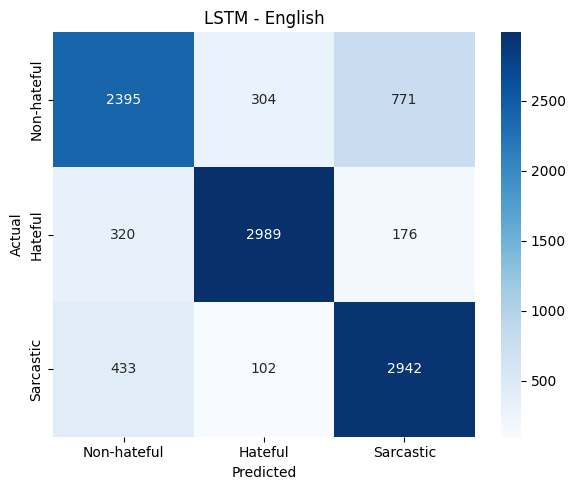


--- BiLSTM ---
  Epoch 1/10 - Loss: 0.7354 - Val Macro F1: 0.7432
  Epoch 3/10 - Loss: 0.5048 - Val Macro F1: 0.7809
  Epoch 6/10 - Loss: 0.3816 - Val Macro F1: 0.8115
  Epoch 9/10 - Loss: 0.3052 - Val Macro F1: 0.8137

BiLSTM - English
Accuracy: 0.8159
Macro F1: 0.8137
              precision    recall  f1-score   support

 Non-hateful       0.81      0.69      0.74      3470
     Hateful       0.87      0.88      0.88      3485
   Sarcastic       0.77      0.88      0.82      3477

    accuracy                           0.82     10432
   macro avg       0.82      0.82      0.81     10432
weighted avg       0.82      0.82      0.81     10432



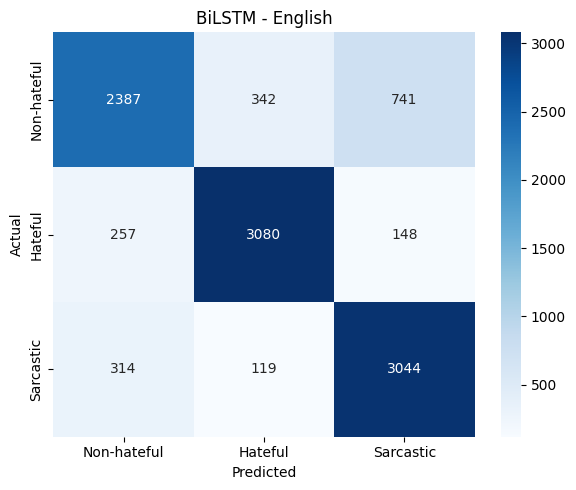


--- CNN ---
  Epoch 1/10 - Loss: 0.7592 - Val Macro F1: 0.7174
  Epoch 3/10 - Loss: 0.4661 - Val Macro F1: 0.7609
  Epoch 6/10 - Loss: 0.2601 - Val Macro F1: 0.7857
  Epoch 9/10 - Loss: 0.1464 - Val Macro F1: 0.7866

CNN - English
Accuracy: 0.7893
Macro F1: 0.7899
              precision    recall  f1-score   support

 Non-hateful       0.72      0.72      0.72      3470
     Hateful       0.89      0.84      0.87      3485
   Sarcastic       0.76      0.80      0.78      3477

    accuracy                           0.79     10432
   macro avg       0.79      0.79      0.79     10432
weighted avg       0.79      0.79      0.79     10432



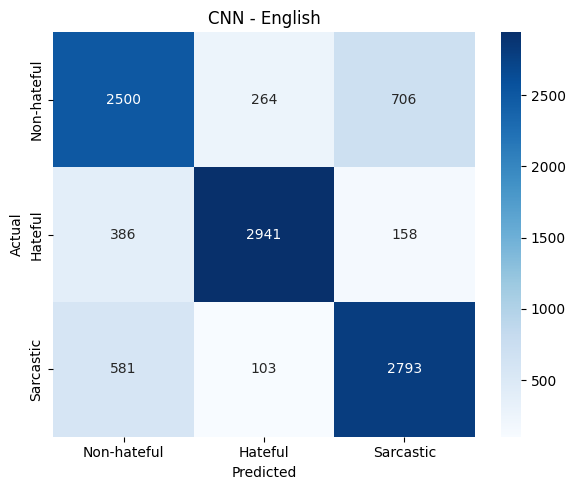

CNNClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (conv3): Conv1d(128, 100, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv4): Conv1d(128, 100, kernel_size=(4,), stride=(1,), padding=(1,))
  (conv5): Conv1d(128, 100, kernel_size=(5,), stride=(1,), padding=(2,))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=300, out_features=3, bias=True)
)

In [11]:
# ============================================================
# 3B: TRAIN DL MODELS ON ENGLISH
# ============================================================
print("=" * 70)
print("TRAINING DEEP LEARNING MODELS - ENGLISH")
print("=" * 70)
 
# Tokenize
tok_en = SimpleTokenizer(max_vocab=30000)
tok_en.fit(en_train['text_clean'].values)
 
train_ds_en = TextDataset(en_train['text_clean'].values, y_en_train, tok_en)
val_ds_en = TextDataset(en_val['text_clean'].values, y_en_val, tok_en)
 
train_loader_en = DataLoader(train_ds_en, batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader_en = DataLoader(val_ds_en, batch_size=256, shuffle=False, collate_fn=collate_fn)
 
vocab_size_en = len(tok_en.word2idx)
 
# LSTM
print("\n--- LSTM ---")
lstm_en = LSTMClassifier(vocab_size_en)
train_dl_model(lstm_en, train_loader_en, val_loader_en, y_en_val, "LSTM", "English")
 
# BiLSTM
print("\n--- BiLSTM ---")
bilstm_en = BiLSTMClassifier(vocab_size_en)
train_dl_model(bilstm_en, train_loader_en, val_loader_en, y_en_val, "BiLSTM", "English")
 
# CNN
print("\n--- CNN ---")
cnn_en = CNNClassifier(vocab_size_en)
train_dl_model(cnn_en, train_loader_en, val_loader_en, y_en_val, "CNN", "English")

TRAINING DEEP LEARNING MODELS - BANGLA
Vocabulary size: 30000
Bangla class weights: [0.67442656 1.09080106 1.66527498]

--- LSTM ---
  Epoch 1/10 - Loss: 1.0987 - Val Macro F1: 0.1171
  Epoch 3/10 - Loss: 1.0843 - Val Macro F1: 0.3286
  Epoch 6/10 - Loss: 0.7629 - Val Macro F1: 0.6445
  Epoch 9/10 - Loss: 0.6744 - Val Macro F1: 0.6193

LSTM - Bangla
Accuracy: 0.6657
Macro F1: 0.6552
              precision    recall  f1-score   support

 Non-hateful       0.70      0.62      0.66      4140
     Hateful       0.82      0.80      0.81      2560
   Sarcastic       0.44      0.58      0.50      1676

    accuracy                           0.67      8376
   macro avg       0.65      0.67      0.66      8376
weighted avg       0.68      0.67      0.67      8376



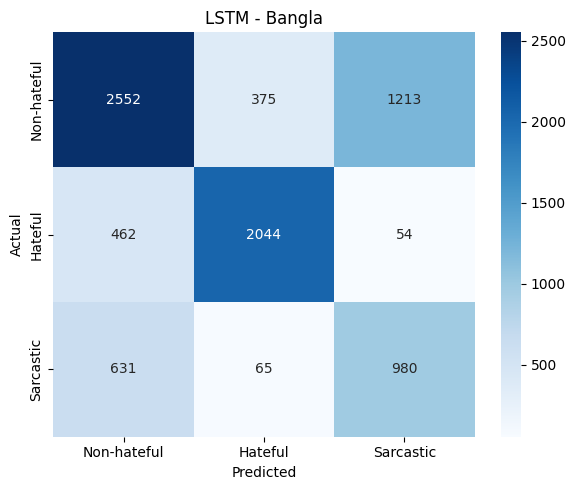


--- BiLSTM ---
  Epoch 1/10 - Loss: 0.8188 - Val Macro F1: 0.6593
  Epoch 3/10 - Loss: 0.5686 - Val Macro F1: 0.7361
  Epoch 6/10 - Loss: 0.4331 - Val Macro F1: 0.7511
  Epoch 9/10 - Loss: 0.3501 - Val Macro F1: 0.7680

BiLSTM - Bangla
Accuracy: 0.7843
Macro F1: 0.7680
              precision    recall  f1-score   support

 Non-hateful       0.80      0.78      0.79      4140
     Hateful       0.87      0.86      0.86      2560
   Sarcastic       0.62      0.67      0.65      1676

    accuracy                           0.78      8376
   macro avg       0.76      0.77      0.77      8376
weighted avg       0.79      0.78      0.79      8376



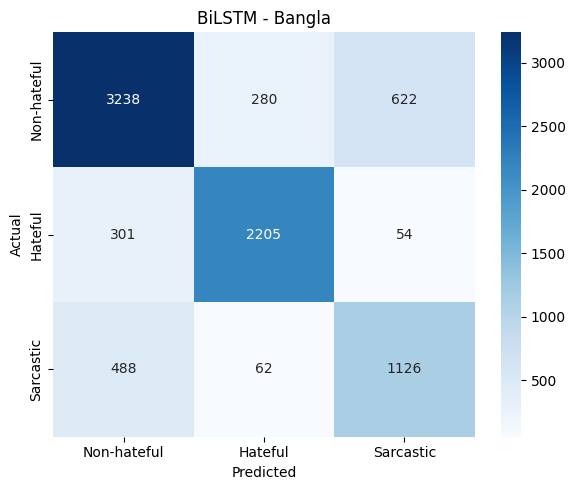


--- CNN ---
  Epoch 1/10 - Loss: 0.8123 - Val Macro F1: 0.6682
  Epoch 3/10 - Loss: 0.5190 - Val Macro F1: 0.7230
  Epoch 6/10 - Loss: 0.3052 - Val Macro F1: 0.7404
  Epoch 9/10 - Loss: 0.1796 - Val Macro F1: 0.7410

CNN - Bangla
Accuracy: 0.7601
Macro F1: 0.7433
              precision    recall  f1-score   support

 Non-hateful       0.78      0.76      0.77      4140
     Hateful       0.85      0.83      0.84      2560
   Sarcastic       0.59      0.64      0.62      1676

    accuracy                           0.76      8376
   macro avg       0.74      0.75      0.74      8376
weighted avg       0.76      0.76      0.76      8376



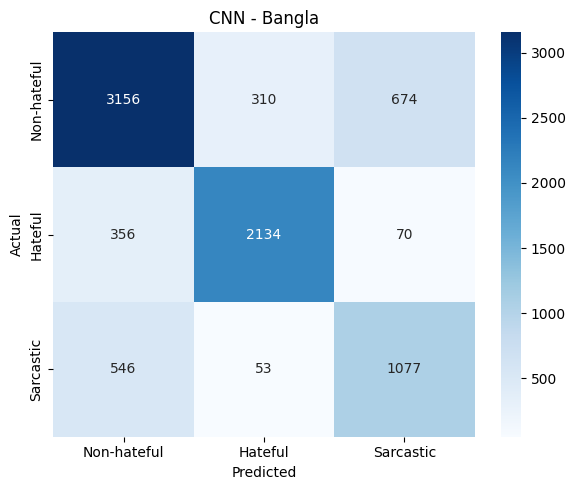

CNNClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (conv3): Conv1d(128, 100, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv4): Conv1d(128, 100, kernel_size=(4,), stride=(1,), padding=(1,))
  (conv5): Conv1d(128, 100, kernel_size=(5,), stride=(1,), padding=(2,))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=300, out_features=3, bias=True)
)

In [12]:
# ============================================================
# 3B: TRAIN DL MODELS ON BANGLA
# ============================================================
print("=" * 70)
print("TRAINING DEEP LEARNING MODELS - BANGLA")
print("=" * 70)
 
tok_bn = SimpleTokenizer(max_vocab=30000)
tok_bn.fit(bn_train['text_clean'].values)
 
train_ds_bn = TextDataset(bn_train['text_clean'].values, y_bn_train, tok_bn)
val_ds_bn = TextDataset(bn_val['text_clean'].values, y_bn_val, tok_bn)
 
train_loader_bn = DataLoader(train_ds_bn, batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader_bn = DataLoader(val_ds_bn, batch_size=256, shuffle=False, collate_fn=collate_fn)
 
vocab_size_bn = len(tok_bn.word2idx)
 
# Compute class weights for Bangla imbalance
cw_bn = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_bn_train)
print(f"Bangla class weights: {cw_bn}")
 
# LSTM
print("\n--- LSTM ---")
lstm_bn = LSTMClassifier(vocab_size_bn)
train_dl_model(lstm_bn, train_loader_bn, val_loader_bn, y_bn_val, "LSTM", "Bangla",
               class_weights=cw_bn)
 
# BiLSTM
print("\n--- BiLSTM ---")
bilstm_bn = BiLSTMClassifier(vocab_size_bn)
train_dl_model(bilstm_bn, train_loader_bn, val_loader_bn, y_bn_val, "BiLSTM", "Bangla",
               class_weights=cw_bn)
 
# CNN
print("\n--- CNN ---")
cnn_bn = CNNClassifier(vocab_size_bn)
train_dl_model(cnn_bn, train_loader_bn, val_loader_bn, y_bn_val, "CNN", "Bangla",
               class_weights=cw_bn)